# Inspect One Patient

Purpose: Before processing all 625 UTSW patients, we will look closely at one subject (in this case, BT0001) to confirm image file layouts and segmentation labels. This will be used to inform the preprocessing and handling of image data for the rest of the project. Most importantly, this notebook will determine which files will be kept and how images will be cropped to save local device storage due to the large dataset size.  

### Loading patient folder

From the project root, the raw UTSW patient files are located in `Data/raw` (which is .gitignored). For the sake of consistency, `src/config.py` stores useful paths which will be used frequenctly throughout the project. 

**Found**: 11 NIfTI (`.nii.gz`) files which is a type of neuroimaging file that stores 3D data in voxels (3D pixels) 
- 4 plain contrasts: T1, T1ce, T2, T2-FLAIR
    - different contrasts alter how the tissue will look
- 4 `*_ants` versions of the plain contrasts 
    - `*_ants` is a software that performs skull stripping which removes the skull and scalp from the image leaving only the brain.  
- 3 segmentations files (FeTS which is an automated tumor segmentation tool (`tumorseg_FeTS`) and 2 manually segmented files)

In [1]:
import nibabel as nib
import numpy as np

from src.config import RAW

case = RAW / "BT0001"
assert case.exists(), "BT0001 not found under RAW"
print(case.name)
print(sorted(p.name for p in case.iterdir()))

BT0001
['brain_fl_ants.nii.gz', 'brain_flair.nii.gz', 'brain_t1.nii.gz', 'brain_t1_ants.nii.gz', 'brain_t1ce.nii.gz', 'brain_t1ce_ants.nii.gz', 'brain_t2.nii.gz', 'brain_t2_ants.nii.gz', 'rtumorseg_manual_correction.nii.gz', 'tumorseg_FeTS.nii.gz', 'tumorseg_manual_correction.nii.gz']


### Inspect Non-Segmented Images
For each of the eight images, we will print shape, voxel size, orientation, how many voxels are above 0 (serves as indicator of the brain), and the mean and max intensity inside the brain.

**Found:**
- All eight images are 240 × 240 × 155 voxels, 1 mm isotropic (consistent with what the dataset states), orientation LPS (Left, Posterior, Superior here).
- The four plain contrasts have exactly the same brain voxel count (1,370,681), so they share one brain mask. The ANTs versions share a different, smaller mask (1,207,446 voxels, about 12% fewer). As expected due to skull-stripping. 
- Intensities are in arbitrary, contrast-specific units (means range from about 313 to 482), so they cannot be compared across scans or contrasts directly. This is why each scan is z-scored separately later.

In [2]:
# Inspect one patient's MRI data
names = ["brain_t1", "brain_t1ce", "brain_t2", "brain_flair",
         "brain_t1_ants", "brain_t1ce_ants", "brain_t2_ants", "brain_fl_ants"]

for name in names:
    img = nib.load(case / f"{name}.nii.gz") 
    data = img.get_fdata() # convert image data to numpy array
    brain = data[data > 0] # assume brain is non-zero voxels
    print(f"{name:16} shape={img.shape} voxel={img.header.get_zooms()} "
          f"orient={''.join(nib.aff2axcodes(img.affine))} "
          f"nonzero={brain.size} mean={brain.mean():.1f} max={data.max():.1f}")

brain_t1         shape=(240, 240, 155) voxel=(np.float32(1.0), np.float32(1.0), np.float32(1.0)) orient=LPS nonzero=1370681 mean=313.0 max=849.2
brain_t1ce       shape=(240, 240, 155) voxel=(np.float32(1.0), np.float32(1.0), np.float32(1.0)) orient=LPS nonzero=1370681 mean=345.8 max=1206.9
brain_t2         shape=(240, 240, 155) voxel=(np.float32(1.0), np.float32(1.0), np.float32(1.0)) orient=LPS nonzero=1370681 mean=481.7 max=1374.9
brain_flair      shape=(240, 240, 155) voxel=(np.float32(1.0), np.float32(1.0), np.float32(1.0)) orient=LPS nonzero=1370681 mean=357.5 max=897.9
brain_t1_ants    shape=(240, 240, 155) voxel=(np.float32(1.0), np.float32(1.0), np.float32(1.0)) orient=LPS nonzero=1207446 mean=323.2 max=1420.3
brain_t1ce_ants  shape=(240, 240, 155) voxel=(np.float32(1.0), np.float32(1.0), np.float32(1.0)) orient=LPS nonzero=1207446 mean=351.6 max=1338.6
brain_t2_ants    shape=(240, 240, 155) voxel=(np.float32(1.0), np.float32(1.0), np.float32(1.0)) orient=LPS nonzero=1207446 me

### Inspect Segmentation Files
Prints each segmentation's shape and number of voxels for each segmentation label. **Segmentation:** a label image the same size as the scan, marking which voxels are tumor. Labels follow the BraTS (Brain Tumor Segmentation Challenge) convention (since not explicitly stated in UTSW dataset paper): 1 = necrotic/non-enhancing core, 2 = edema, 4 = enhancing tumor.

**Found:**
- `tumorseg_FeTS` is full size (240 × 240 × 155) with labels 0, 1, 2, 4 and 149,604 tumor voxels in total.
- `tumorseg_manual_correction` is already cropped to 74 × 93 × 63, the same size as the FeTS tumor bounding box (found in future cell). `rtumorseg_manual_correction` has the same label counts on the full-size grid.
- Manual and automated labels differ slightly for this patient (150,416 vs 149,604 tumor voxels).
- Manual refinement exists for only 362 of 625 patients, so FeTS is the only segmentation available for all patients. Segmentation files will be used only to locate the tumor for cropping, never as a feature.

In [3]:
# Inspect one patient's segmentation data
for name in ["tumorseg_FeTS", "tumorseg_manual_correction", "rtumorseg_manual_correction"]:
    f = case / f"{name}.nii.gz"
    if f.exists():
        seg = nib.load(f)
        vals, counts = np.unique(seg.get_fdata().astype(int), return_counts=True)
        print(name, seg.shape, dict(zip(vals.tolist(), counts.tolist())))

tumorseg_FeTS (240, 240, 155) {0: 8778396, 1: 30073, 2: 79744, 4: 39787}
tumorseg_manual_correction (74, 93, 63) {0: 283150, 1: 26557, 2: 82624, 4: 41235}
rtumorseg_manual_correction (240, 240, 155) {0: 8777584, 1: 26557, 2: 82624, 4: 41235}


### Does either brain mask cut into the tumor?
Three checks:
1. What fraction of FeTS tumor voxels fall inside each brain mask (plain vs ANTs T1ce).
2. Whether the FeTS segmentation shares the T1ce affine (same physical grid).
    - **Affine:** a 4×4 matrix that converts voxel indices to physical positions in mm. Two images with the same shape and affine line up voxel for voxel.
    - This ensures that the crop is properly centered based on the segmentation. 
3. A mid-tumor slice of both T1ce versions with the FeTS outline in red. Visual representation of check (1). 

**Found:** 100% of tumor voxels lie inside the plain mask but only 95.7% inside the `*_ants` mask. In the figure, the lower edge of the tumor extends past the ANTs brain boundary, so skull stripping seems to have removed real tumor. The affine check is `True`.

**Decision:** use the four plain contrasts and drop the `*_ants` files.

**Caveat:** this is one patient. The same fraction should be computed across all patients (notebook 02) before treating the choice as settled.

brain_t1ce fraction of tumor inside brain mask: 1.0
brain_t1ce_ants fraction of tumor inside brain mask: 0.957
affines match: True


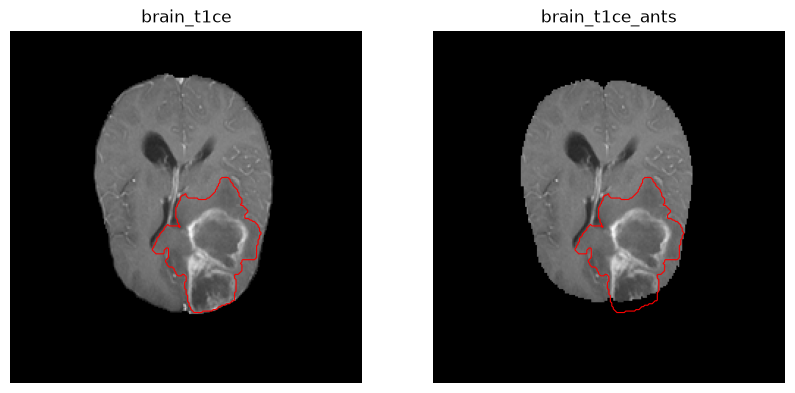

In [4]:
import matplotlib.pyplot as plt

def load(name):
    return nib.load(case / f"{name}.nii.gz").get_fdata()

fets = load("tumorseg_FeTS") > 0

# Check 1: does either brain mask clip into the tumor?
for name in ["brain_t1ce", "brain_t1ce_ants"]:
    brain = load(name) > 0
    # number of voxels in the tumor that are also in the brain mask, divided by total tumor voxels
    print(name, "fraction of tumor inside brain mask:", round((fets & brain).sum() / fets.sum(), 4))

# Check 2: confirm the FeTS segmentation shares the MRI's coordinate grid
print("affines match:", np.allclose(nib.load(case / "tumorseg_FeTS.nii.gz").affine,
                                    nib.load(case / "brain_t1ce.nii.gz").affine))

# Check 3: eyeball both versions with the FeTS tumor outline
z = int(np.argwhere(fets)[:, 2].mean())
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, name in zip(axes, ["brain_t1ce", "brain_t1ce_ants"]):
    ax.imshow(load(name)[:, :, z].T, cmap="gray", origin="lower")
    ax.contour(fets[:, :, z].T, colors="red", linewidths=0.8)
    ax.set_title(name); ax.axis("off")
plt.show()

### The Preprocessing Workflow
Preprocessing code and functions used (`zscore_brain`, `crop_center`, and `process_case`) have all been moved to `src/preprocessing.py`. Here are the descriptions of what `preprocessing.py` does:

- `zscore_brain`: per-scan z-score (subtract the brain mean, divide by the brain standard deviation) using only voxels above 0, computed on the whole brain before cropping. Background stays 0. Method of normalization of MRI intensities. This is especially useful for the UTSW dataset, since different MRI machines with different strengths were used. 
- `crop_center`: cuts a fixed 96 x 96 x 96 window around a point and zero-pads wherever the window leaves the volume.
- `process_case`: finds the tumor's **bounding box** (smallest box containing all tumor voxels) from the FeTS segmentation (label > 0, i.e. whole tumor), centers the window on it, crops all four contrasts and the segmentation, and stacks the contrasts as channels in a fixed order. Stored as float16 to save memory.

**Found:** output shape `(4, 96, 96, 96)`; 63% of the first channel's voxels are nonzero (brain); the tumor bounding box is 74 x 93 x 63.

**Note:** the crop size of 96 is provisional. This tumor already spans 93 voxels along one axis, so larger tumors will be clipped. Choose the final size from the bounding-box distribution across all patients (`processing_log.csv`). 

In [ ]:
from src.preprocessing import process_case, CROP, CONTRASTS

r = process_case(case)
img, seg_crop, bbox = r["image"], r["mask"], r["bbox"] # r is a dict with keys: image, mask, bbox, tumor_in_brain

print(img.shape, img.dtype, "tumor bbox:", bbox,
      "nonzero fraction:", round(float((img[0] != 0).mean()), 3),
      "tumor in brain:", round(r["tumor_in_brain"], 4))

(4, 96, 96, 96) float16 tumor bbox: [74 93 63] nonzero fraction: 0.632 tumor in brain: 1.0


### Sanity-check the cropped result
Prints the mean and standard deviation of the nonzero voxels in channel 1 (T1ce), then shows the center slice of all four channels with the tumor outline.

**Found:** mean −0.027 and std 0.982, close to 0 and 1 but not exact, because the z-score used the whole brain and the crop contains only part of it. The outline sits on the abnormal signal in all four contrasts, so the crop and the segmentation are aligned.

**Note:** in the figure the background looks mid-gray, not black. After z-scoring, background (0) equals the average brain intensity, so intensity alone cannot separate background from normal tissue. Worth keeping in mind when designing the model input.

### Decisions carried forward
- Inputs: `brain_t1`, `brain_t1ce`, `brain_t2`, `brain_flair`, in that channel order (the same order must be used for UCSF-PDGM).
- Tumor location comes from `tumorseg_FeTS` for all patients.
- Per-scan z-score inside the brain; background stays 0.
- Crop: fixed 96 x 96 x 96 window centered on the tumor bounding box, subject to change.

brain mean/std of channel 1: -0.027 0.982


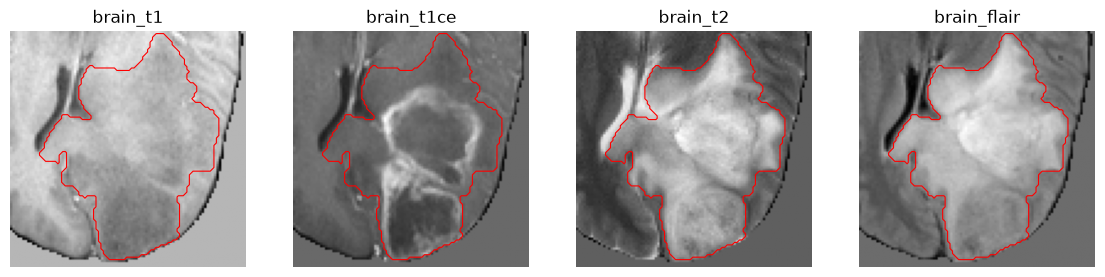

In [8]:
print("brain mean/std of channel 1:", img[1][img[1] != 0].astype(np.float32).mean().round(3),
      img[1][img[1] != 0].astype(np.float32).std().round(3))

z = CROP // 2
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, c, name in zip(axes, img, CONTRASTS):
    ax.imshow(c[:, :, z].T.astype(np.float32), cmap="gray", origin="lower")
    ax.contour((seg_crop[:, :, z] > 0).T, colors="red", linewidths=0.8)
    ax.set_title(name); ax.axis("off")
plt.show()